# Circle Packing with GEPA: An Optimization Walkthrough

This notebook walks through how **GEPA** (Generalized Evolutionary Prompt Architecture) optimizes a circle packing algorithm. The goal: pack 26 non-overlapping circles inside a unit square `[0,1]×[0,1]` to **maximize the sum of all radii**.

GEPA co-evolves **two components**:
1. **Code** — the circle packing algorithm itself
2. **Refiner prompt** — instructions that guide a second LLM to improve the code

A full GEPA run takes hours and many API calls. This notebook replays a completed run **instantly** using pre-recorded candidates and cached evaluation results — no API key needed.

## 1. Setup & Imports

In [1]:
import json
import pickle
import sys
import types
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Stub dspy so we can import llms.py without that dependency
if "dspy" not in sys.modules:
    _stub = types.ModuleType("dspy")
    _stub.Signature = type("Signature", (), {})
    _stub.InputField = lambda **kw: None
    _stub.OutputField = lambda **kw: None
    sys.modules["dspy"] = _stub

from gepa.core.state import GEPAState, _candidate_hash

## 2. The Problem

Pack **N = 26** circles inside a unit square. Each circle has center `(x, y)` and radius `r`. Constraints:
- Every circle must be fully inside the square: `r ≤ x ≤ 1−r` and `r ≤ y ≤ 1−r`
- No two circles may overlap: distance between centers ≥ sum of radii
- All radii must be positive

**Objective:** maximize `Σ rᵢ` (sum of all radii).

## 3. The Seed Code

GEPA starts from a simple seed — a naive placement with a center circle, an inner ring, and an outer ring:

In [2]:
from utils import SEED_CODE
print(SEED_CODE)


import numpy as np

def main(timeout, current_best_solution):
    """
    Circle packing optimization.

    Args:
        timeout: Time budget in seconds
        current_best_solution: Previous best circles array (n, 3) or None

    Returns:
        dict with 'circles' (n, 3) array and 'all_scores' list
    """
    n = 26

    # Use current_best_solution if provided, otherwise start fresh
    if current_best_solution is not None:
        circles = current_best_solution.copy()
    else:
        # Simple initial placement
        centers = np.zeros((n, 2))

        # Center circle
        centers[0] = [0.5, 0.5]

        # Ring of 8 around center
        for i in range(min(8, n - 1)):
            angle = 2 * np.pi * i / 8
            centers[i + 1] = [0.5 + 0.3 * np.cos(angle), 0.5 + 0.3 * np.sin(angle)]

        # Outer ring for remaining
        if n > 9:
            remaining = n - 9
            for i in range(remaining):
                angle = 2 * np.pi * i / remaining
            

This seed scores about **0.98** — many circles are tiny because they're crammed into poor positions. GEPA's job is to evolve this into something much better.

## 4. GEPA's Two-Component Optimization

GEPA maintains a **population of candidates**, each containing two text components:

| Component | What it is | Who uses it |
|-----------|-----------|-------------|
| `code` | The packing algorithm | Executed directly to produce circles |
| `refiner_prompt` | Instructions for code improvement | Fed to a second LLM that refines the code |

Each iteration:
1. **Select** a parent candidate from the population
2. **Propose** a mutation to one component (code OR refiner_prompt) via an LLM
3. **Evaluate** the new candidate: run the code, then refine it, take the best score
4. **Accept** if the new candidate improves on the parent's score

## 5. Loading the Recorded Run

We load the saved GEPA state from a completed optimization run. This contains all 28 candidates explored, their parent chains, and cached evaluation results.

In [3]:
state = GEPAState.load("output")

candidates = state.program_candidates
parents = state.parent_program_for_candidate
cache = state.evaluation_cache._cache

# Build a score lookup
def get_score(idx):
    h = _candidate_hash(candidates[idx])
    entry = cache.get((h, 0))
    return entry.score if entry else 0.0

def get_output(idx):
    h = _candidate_hash(candidates[idx])
    entry = cache.get((h, 0))
    return entry.output if entry else {}

print(f"Candidates explored: {len(candidates)}")
print(f"Evaluation cache entries: {len(cache)}")
print(f"Total GEPA iterations: {state.i}")

Candidates explored: 28
Evaluation cache entries: 88
Total GEPA iterations: 86


## 6. Score Progression

Let's visualize how scores improved over the 28 accepted candidates:

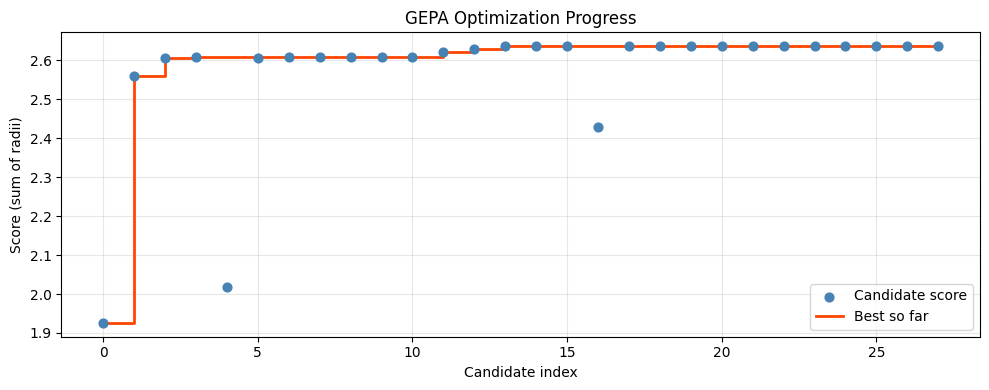

Seed score:  1.9259
Best score:  2.6360
Improvement: 0.7101 (36.9%)


In [4]:
scores = [get_score(i) for i in range(len(candidates))]
best_so_far = np.maximum.accumulate(scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(scores)), scores, c='steelblue', s=40, zorder=3, label='Candidate score')
ax.step(range(len(best_so_far)), best_so_far, where='post', color='orangered',
        linewidth=2, label='Best so far')
ax.set_xlabel('Candidate index')
ax.set_ylabel('Score (sum of radii)')
ax.set_title('GEPA Optimization Progress')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Seed score:  {scores[0]:.4f}")
print(f"Best score:  {max(scores):.4f}")
print(f"Improvement: {max(scores) - scores[0]:.4f} ({(max(scores)/scores[0] - 1)*100:.1f}%)")

## 7. What Changed at Each Step

GEPA uses **round-robin component selection** — it alternates between mutating `code` and `refiner_prompt`. Let's see the parent chain and which component was updated:

In [5]:
print(f"{'Idx':>3}  {'Parent':>6}  {'Changed':>16}  {'Score':>8}  {'Best':>8}")
print("-" * 50)
best = 0
for i in range(len(candidates)):
    score = get_score(i)
    best = max(best, score)
    if parents[i][0] is None:
        print(f"{i:3d}  {'seed':>6}  {'—':>16}  {score:8.4f}  {best:8.4f}")
        continue
    parent_idx = parents[i][0]
    parent = candidates[parent_idx]
    child = candidates[i]
    changed = [k for k in parent if parent[k] != child[k]]
    comp = changed[0] if changed else '?'
    marker = ' *' if score > get_score(parent_idx) else ''
    print(f"{i:3d}  {parent_idx:6d}  {comp:>16}  {score:8.4f}  {best:8.4f}{marker}")

Idx  Parent           Changed     Score      Best
--------------------------------------------------
  0    seed                 —    1.9259    1.9259
  1       0              code    2.5590    2.5590 *
  2       1    refiner_prompt    2.6058    2.6058 *
  3       0    refiner_prompt    2.6084    2.6084 *
  4       0              code    2.0169    2.6084 *
  5       2    refiner_prompt    2.6058    2.6084 *
  6       5              code    2.6071    2.6084 *
  7       6              code    2.6071    2.6084 *
  8       0    refiner_prompt    2.6084    2.6084 *
  9       0              code    2.6084    2.6084 *
 10       4              code    2.6084    2.6084 *
 11       9    refiner_prompt    2.6203    2.6203 *
 12      11              code    2.6299    2.6299 *
 13      12              code    2.6360    2.6360 *
 14      13    refiner_prompt    2.6360    2.6360 *
 15       0    refiner_prompt    2.6360    2.6360 *
 16       4              code    2.4293    2.6360 *
 17       0      

## 8. Visualizing Circle Packings

Let's compare the seed packing with the best solution found:

In [6]:
def plot_packing(circles, title, ax):
    """Plot a circle packing inside the unit square."""
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    # Unit square
    square = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(square)
    # Circles
    cmap = plt.cm.viridis
    radii = [c[2] for c in circles]
    max_r = max(radii) if radii else 1
    for x, y, r in circles:
        color = cmap(r / max_r * 0.8 + 0.1)
        circle = plt.Circle((x, y), r, fill=True, facecolor=color, edgecolor='black',
                           linewidth=0.5, alpha=0.7)
        ax.add_patch(circle)
    sum_r = sum(radii)
    ax.set_title(f"{title}\nSum of radii = {sum_r:.4f}", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

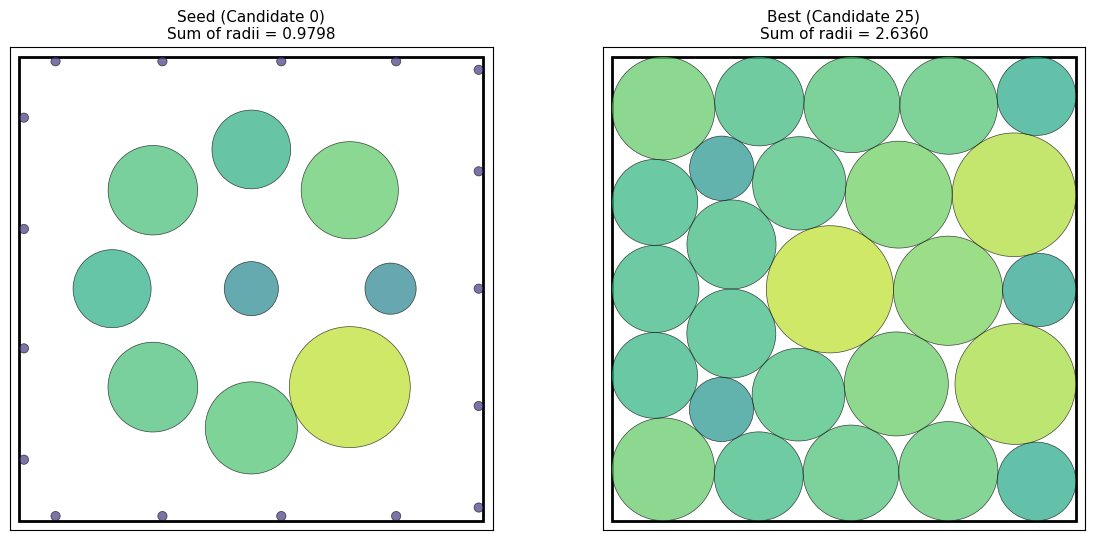

In [7]:
# Get seed packing (from state_tracker_logs)
with open("output/state_tracker_logs.json") as f:
    logs = json.load(f)

seed_circles = np.array(json.loads(logs[0]["best_solution"]))

# Get best packing
best_idx = max(range(len(candidates)), key=lambda i: get_score(i))
best_output = get_output(best_idx)
best_circles = np.array(best_output["best_circles"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
plot_packing(seed_circles, "Seed (Candidate 0)", axes[0])
plot_packing(best_circles, f"Best (Candidate {best_idx})", axes[1])
plt.tight_layout()
plt.show()

## 9. The Evolution of Code

Let's look at how the code evolved. The first big improvement (candidate 1) replaced the simple ring layout with a much more sophisticated approach:

In [8]:
# Show the key algorithmic ideas at major score jumps
milestones = []
best = 0
for i, s in enumerate(scores):
    if s > best + 0.01:  # significant improvement
        best = s
        milestones.append(i)

for idx in milestones:
    output = get_output(idx)
    code = output.get("best_code", candidates[idx]["code"])
    # Extract first docstring or key functions
    lines = code.split('\n')
    # Find function definitions
    funcs = [l.strip() for l in lines if l.strip().startswith('def ')]
    print(f"--- Candidate {idx} (score: {scores[idx]:.4f}) ---")
    print(f"    Functions: {', '.join(funcs[:6])}")
    print(f"    Code length: {len(code)} chars ({len(lines)} lines)")
    print()

--- Candidate 0 (score: 1.9259) ---
    Functions: def compute_max_radii(centers):, def project_inside_square(centers, radii):, def local_optimize(centers, radii, time_budget):, def random_perturbation(centers, scale=0.02):, def build_initial_centers(n):, def main(timeout, current_best_solution):
    Code length: 7680 chars (231 lines)

--- Candidate 1 (score: 2.5590) ---
    Functions: def main(timeout, current_best_solution):, def compute_radii_lp(centers):, def _pair_row(N, i, j):, def compute_radii_fallback(centers):, def score_radii(r):, def ensure_valid_centers(centers, eps=1e-3):
    Code length: 14491 chars (421 lines)

--- Candidate 2 (score: 2.6058) ---
    Functions: def main(timeout, current_best_solution):, def compute_radii_lp(centers):, def compute_radii_fallback(centers):, def ensure_valid_centers(centers, eps=1e-3):, def generate_hex_seeds(n, rng):, def generate_random_seeds(n, rng):
    Code length: 18371 chars (485 lines)

--- Candidate 11 (score: 2.6203) ---
    Fun

## 10. Intermediate Packings

Let's visualize packings at key milestones to see the geometric improvement:

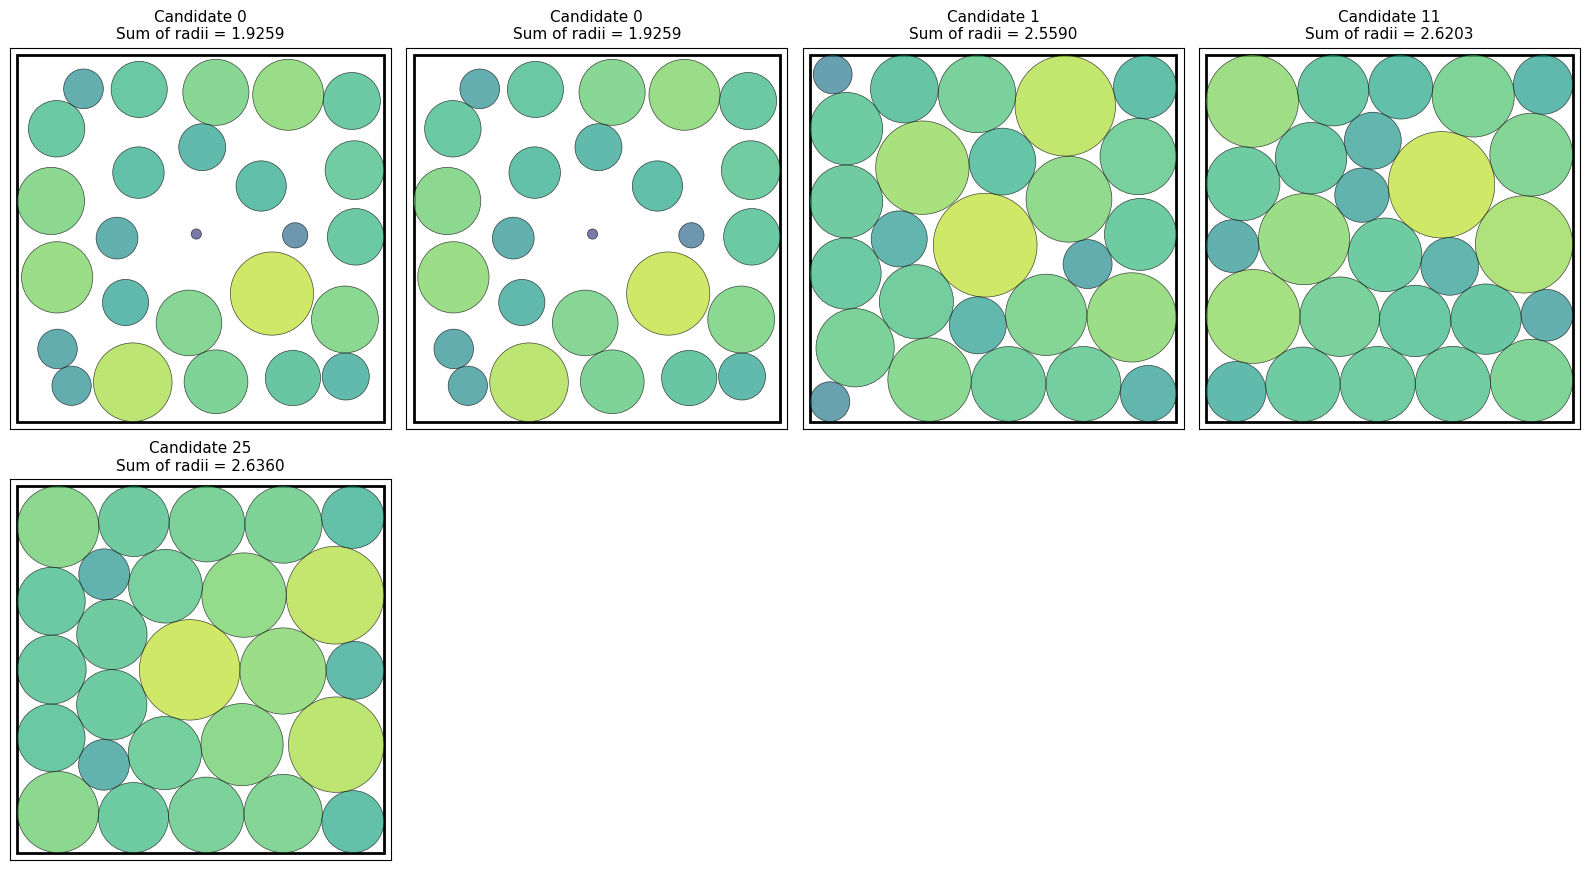

In [9]:
# Pick a few milestone candidates to visualize
show_indices = [0]  # always show seed
best = 0
for i, s in enumerate(scores):
    if s > best + 0.05:
        best = s
        show_indices.append(i)
# Always include the final best
if show_indices[-1] != best_idx:
    show_indices.append(best_idx)

ncols = min(len(show_indices), 4)
nrows = (len(show_indices) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows))
if nrows == 1 and ncols == 1:
    axes = np.array([axes])
axes = np.atleast_2d(axes)

for k, idx in enumerate(show_indices):
    row, col = divmod(k, ncols)
    ax = axes[row, col]
    output = get_output(idx)
    circles = output.get("best_circles")
    if circles is None:
        # For seed, use state tracker logs
        circles = json.loads(logs[0]["best_solution"])
    plot_packing(circles, f"Candidate {idx}", ax)

# Hide unused axes
for k in range(len(show_indices), nrows * ncols):
    row, col = divmod(k, ncols)
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()

## 11. Replaying the Optimization with GEPA

Now let's actually **run GEPA's optimization loop** using our replay infrastructure. This uses:
- `ReplayProposer` — feeds the exact candidates from the original run
- `create_replay_evaluator` — returns cached scores without executing any code

The result: a full GEPA run in under a second, with real progress logs.

In [10]:
import os
import time

from llms import CIRCLE_PACKING_BACKGROUND, SEED_REFINEMENT_PROMPT
from utils import SEED_CODE
from gepa.optimize_anything import (
    EngineConfig, GEPAConfig, ReflectionConfig, optimize_anything,
)
from recorder import ReplayProposer, create_replay_evaluator

# Load pre-recorded data
with open("recordings/evaluation_cache.pkl", "rb") as f:
    cache_data = pickle.load(f)

print(f"Loaded {len(cache_data['cache'])} cached evaluations")
print(f"Loaded {len(cache_data['candidates'])} candidates")

Loaded 88 cached evaluations
Loaded 28 candidates


In [11]:
# Set up replay components
replay_proposer = ReplayProposer(cache_data["candidates"])
replay_eval = create_replay_evaluator(cache_data["cache"])

seed_candidate = {"code": SEED_CODE, "refiner_prompt": SEED_REFINEMENT_PROMPT}
num_proposals = len(cache_data["candidates"]) - 1

log_dir = f"outputs/artifacts/circle_packing/notebook_replay_{time.strftime('%y%m%d_%H%M%S')}"
os.makedirs(log_dir, exist_ok=True)

gepa_config = GEPAConfig(
    engine=EngineConfig(
        run_dir=log_dir,
        track_best_outputs=True,
        frontier_type="objective",
        cache_evaluation=True,
        use_cloudpickle=False,
        max_candidate_proposals=num_proposals,
    ),
    reflection=ReflectionConfig(
        reflection_lm=None,
        custom_candidate_proposer=replay_proposer,
    ),
)

print(f"Ready to replay {num_proposals} candidate proposals")

ReplayEvaluator: loaded 88 cached evaluations
Ready to replay 27 candidate proposals


In [12]:
%%time

# Run the full GEPA optimization loop — instantly!
result = optimize_anything(
    seed_candidate=seed_candidate,
    evaluator=replay_eval,
    config=gepa_config,
    objective="Optimize circle packing code and refiner prompt to maximize sum of circle radii within a unit square for N=26 circles.",
    background=CIRCLE_PACKING_BACKGROUND,
)

Iteration 0: Base program full valset score: 1.9258784076439925 over 1 / 1 examples
Iteration 1: Selected program 0 score: 1.9258784076439925
Iteration 1: Proposed new text for code: import numpy as np
import time

def main(timeout, current_best_solution):
    n = 26
    start_time = time.time()
    deadline = start_time + float(timeout)

    rng = np.random.default_rng(12345 + int((start_time * 1e6) % 1e6))

    # Helper: compute radii via LP (SciPy Highs); fallback to conservative shrink if SciPy unavailable
    def compute_radii_lp(centers):
        try:
            from scipy.optimize import linprog
        except Exception:
            return compute_radii_fallback(centers), False

        N = centers.shape[0]
        # Distances to borders
        b = np.minimum.reduce([centers[:,0], centers[:,1], 1.0 - centers[:,0], 1.0 - centers[:,1]])
        # Build constraints: r_i <= b_i and r_i + r_j <= d_ij
        # A_ub x <= b_ub
        rows = []
        rhs = []
        # r_i <= b_i
 

In [13]:
print(f"GEPA explored {result.num_candidates} candidates")
print(f"Best score: {result.val_aggregate_scores[result.best_idx]:.4f}")
print(f"Best candidate index: {result.best_idx}")

GEPA explored 20 candidates
Best score: 2.6360
Best candidate index: 18


## 12. Radius Distribution

Let's examine the distribution of radii in the seed vs. the best solution:

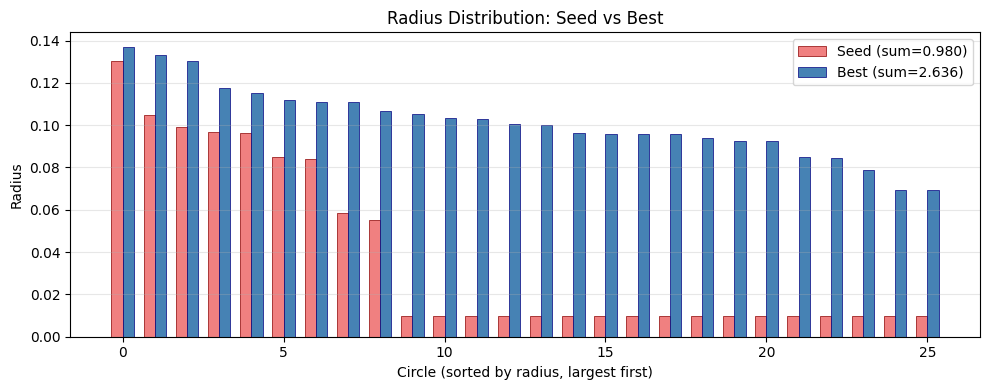

Seed:  min_r=0.0100, max_r=0.1303, mean_r=0.0377
Best:  min_r=0.0692, max_r=0.1370, mean_r=0.1014


In [14]:
seed_radii = sorted(seed_circles[:, 2], reverse=True)
best_radii = sorted(best_circles[:, 2], reverse=True)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(26)
width = 0.35
ax.bar(x - width/2, seed_radii, width, label=f'Seed (sum={sum(seed_radii):.3f})',
       color='lightcoral', edgecolor='darkred', linewidth=0.5)
ax.bar(x + width/2, best_radii, width, label=f'Best (sum={sum(best_radii):.3f})',
       color='steelblue', edgecolor='navy', linewidth=0.5)
ax.set_xlabel('Circle (sorted by radius, largest first)')
ax.set_ylabel('Radius')
ax.set_title('Radius Distribution: Seed vs Best')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Seed:  min_r={min(seed_radii):.4f}, max_r={max(seed_radii):.4f}, "
      f"mean_r={np.mean(seed_radii):.4f}")
print(f"Best:  min_r={min(best_radii):.4f}, max_r={max(best_radii):.4f}, "
      f"mean_r={np.mean(best_radii):.4f}")

## 13. How the Replay Infrastructure Works

The replay system has three pieces:

### `extract_recordings.py`
Reads `output/gepa_state.bin` (the saved GEPA state) and extracts:
- **Candidate list** — the 28 candidate dicts `{code, refiner_prompt}`
- **Evaluation cache** — maps `candidate_hash → (score, objective_scores)`

### `ReplayProposer` (in `recorder.py`)
A custom candidate proposer that feeds pre-recorded candidates in sequence. It returns **all components** of each candidate, so the result is independent of which parent GEPA's selector picks.

### `create_replay_evaluator` (in `recorder.py`)
Creates an evaluator that looks up pre-cached scores by candidate hash. When GEPA calls `evaluator(candidate)`, it computes `sha256(sorted(candidate.items()))` and returns the cached `(score, side_info)` — no code execution needed.

### `RecorderLM` (in `recorder.py`)
For recording **new** runs, `RecorderLM` wraps the real LLM, saving every response to a JSONL file. In replay mode, it returns responses from that file in order. (Used with `--record` / `--replay` flags in `main.py`.)

## 14. The Best Code

Finally, let's look at the best code GEPA evolved:

In [15]:
best_code = get_output(best_idx)["best_code"]
# Show first 80 lines for readability
lines = best_code.strip().split('\n')
print(f"Best code: {len(lines)} lines, {len(best_code)} characters")
print(f"Score: {get_score(best_idx):.4f}")
print()
for i, line in enumerate(lines[:80], 1):
    print(f"{i:3d} | {line}")
if len(lines) > 80:
    print(f"    ... ({len(lines) - 80} more lines)")

Best code: 547 lines, 21041 characters
Score: 2.6360

  1 | import numpy as np
  2 | import time
  3 | 
  4 | def main(timeout, current_best_solution):
  5 |     """
  6 |     BREAKTHROUGH approach: Large-Neighborhood Sequential Linear Programming (LN-SLP)
  7 |     with exact LP for radii. We optimize centers by repeatedly solving LPs over
  8 |     subsets of centers with linearized pairwise constraints and boundary constraints.
  9 |     Multi-start + global SLP + LNS refinement + dual-informed subset selection.
 10 |     """
 11 |     n = 26
 12 |     start_time = time.time()
 13 |     time_budget = max(1.0, float(timeout) - 0.5)
 14 |     rng = np.random.default_rng(2026)
 15 |     eps = 1e-6
 16 |     r_min = 1e-8
 17 |     all_scores = []
 18 | 
 19 |     def time_left():
 20 |         return time_budget - (time.time() - start_time)
 21 | 
 22 |     def clamp01(xy):
 23 |         return np.clip(xy, eps, 1.0 - eps)
 24 | 
 25 |     def boundary_limits(centers):
 26 |         x = 